# 1、加载数据


In [34]:
# 数据来源 https://movie.douban.com/top250
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']

df = pd.read_csv('top250_movie.csv',sep='#')
df.head()
# df.sample(5)
# df.shape

,movie_num,movie_name,movie_year,movie_country,movie_type,movie_director,movie_assess,movie_score,movie_url,movie_intro
0,1,肖申克的救赎,1994,美国,犯罪 剧情,弗兰克·德拉邦特 Frank Darabont,1371845,9.6,https://movie.douban.com/subject/1292052/,希望让人自由。
1,2,霸王别姬,1993,中国大陆 香港,剧情 爱情 同性,陈凯歌 Kaige Chen,1014426,9.6,https://movie.douban.com/subject/1291546/,风华绝代。
2,3,这个杀手不太冷,1994,法国,剧情 动作 犯罪,吕克·贝松 Luc Besson,1254222,9.4,https://movie.douban.com/subject/1295644/,怪蜀黍和小萝莉不得不说的故事。
3,4,阿甘正传,1994,美国,剧情 爱情,罗伯特·泽米吉斯 Robert Zemeckis,1080698,9.4,https://movie.douban.com/subject/1292720/,一部美国近现代史。
4,5,美丽人生,1997,意大利,剧情 喜剧 爱情 战争,罗伯托·贝尼尼 Roberto Benigni,632080,9.5,https://movie.douban.com/subject/1292063/,最美的谎言。


# 2、查看数据基本信息


In [35]:
# 查看数据基本信息，查看各字段是否有缺失值
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_num       250 non-null    int64  
 1   movie_name      250 non-null    str    
 2   movie_year      250 non-null    str    
 3   movie_country   250 non-null    str    
 4   movie_type      250 non-null    str    
 5   movie_director  250 non-null    str    
 6   movie_assess    250 non-null    int64  
 7   movie_score     250 non-null    float64
 8   movie_url       250 non-null    str    
 9   movie_intro     245 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 60.1 KB


# 3、重复值检查


In [36]:
df.duplicated().value_counts()
#检查是否有重名电影
# len(df.movie_name.unique()) # 值小于df.movie_name列的总行数，那么表示存在重复的值

False    250
Name: count, dtype: int64

# 4、国家或者地区上榜数的排名情况


In [37]:
# 对于 country 列，有些电影由多个国家或地区联合制作
country =df['movie_country'].str.split(' ').apply(pd.Series) # 按照空格分割成列表，并转换成Dataframe的列d
print(country)

        0    1    2    3    4    5
0      美国  NaN  NaN  NaN  NaN  NaN
1    中国大陆   香港  NaN  NaN  NaN  NaN
2      法国  NaN  NaN  NaN  NaN  NaN
3      美国  NaN  NaN  NaN  NaN  NaN
4     意大利  NaN  NaN  NaN  NaN  NaN
..    ...  ...  ...  ...  ...  ...
245    美国   英国  NaN  NaN  NaN  NaN
246    美国  NaN  NaN  NaN  NaN  NaN
247  中国大陆  NaN  NaN  NaN  NaN  NaN
248    美国   香港  NaN  NaN  NaN  NaN
249    香港  NaN  NaN  NaN  NaN  NaN

[250 rows x 6 columns]


In [38]:
# 统计每个区域里相同国家的总数,将空值 NaN 替换为“0”
# pd.value_counts是pandas库中的一个函数，用于统计Series中各个元素出现的次数。
# 由于country DataFrame的每一列都包含了一些国家或地区的名称，
# apply函数将pd.value_counts应用到这些列上，分别计算每个国家或地区名称的出现次数。
# all_country = country.apply(pd.value_counts).fillna('0').astype(int)
all_country = country.apply(lambda x: x.value_counts()).fillna(0).astype(int)  # 新方法
print(all_country)
print("="*50)

all_country.columns = ['area1','area2','area3','area4','area5','area6']
# all_country['area1'] = all_country['area1'].astype(int)
# all_country['area2'] = all_country['area2'].astype(int)
# all_country['area3'] = all_country['area3'].astype(int)
# all_country['area4'] = all_country['area4'].astype(int)
# all_country['area5'] = all_country['area5'].astype(int)
# all_country['area6'] = all_country['area6'].astype(int)

# 计算每个国家参与制作电影总数排名情况
all_country['all_counts'] = all_country['area1']+all_country['area2']+all_country['area3']+all_country['area4']+all_country['area5']+all_country['area6']


#按照'all_counts'列的值进行降序排序
all_country = all_country.sort_values(['all_counts'],ascending=False)

all_country.head(5)
#list(all_country.index)

        0   1  2  3  4  5
中国大陆   14   4  1  0  0  0
丹麦      1   0  0  0  0  0
伊朗      2   0  0  0  0  0
冰岛      0   0  0  1  0  0
加拿大     0   5  1  1  0  0
南非      0   1  1  0  0  0
印度      4   0  0  0  0  0
台湾      4   2  0  0  0  0
奥地利     0   1  0  0  0  0
巴西      1   0  1  0  0  0
希腊      0   1  0  0  0  0
德国      5  11  2  0  0  1
意大利     8   1  2  0  0  0
捷克      0   0  1  0  0  0
新西兰     1   2  0  0  0  0
日本     31   2  0  0  0  0
法国      9   9  1  1  0  0
波兰      0   0  0  1  0  0
泰国      1   0  0  0  0  0
澳大利亚    2   5  0  0  0  0
爱尔兰     1   0  0  0  0  0
瑞典      1   1  0  0  0  0
瑞士      0   3  1  0  0  0
美国    122  14  2  5  1  0
英国     14  15  4  0  0  0
荷兰      0   0  0  0  1  0
西德      0   0  1  0  0  0
西班牙     1   2  2  0  0  0
阿根廷     1   0  0  0  0  0
阿联酋     0   0  0  0  1  0
韩国      8   0  1  0  0  0
香港     19   8  0  0  0  0


,area1,area2,area3,area4,area5,area6,all_counts
美国,122,14,2,5,1,0,144
日本,31,2,0,0,0,0,33
英国,14,15,4,0,0,0,33
香港,19,8,0,0,0,0,27
法国,9,9,1,1,0,0,20


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

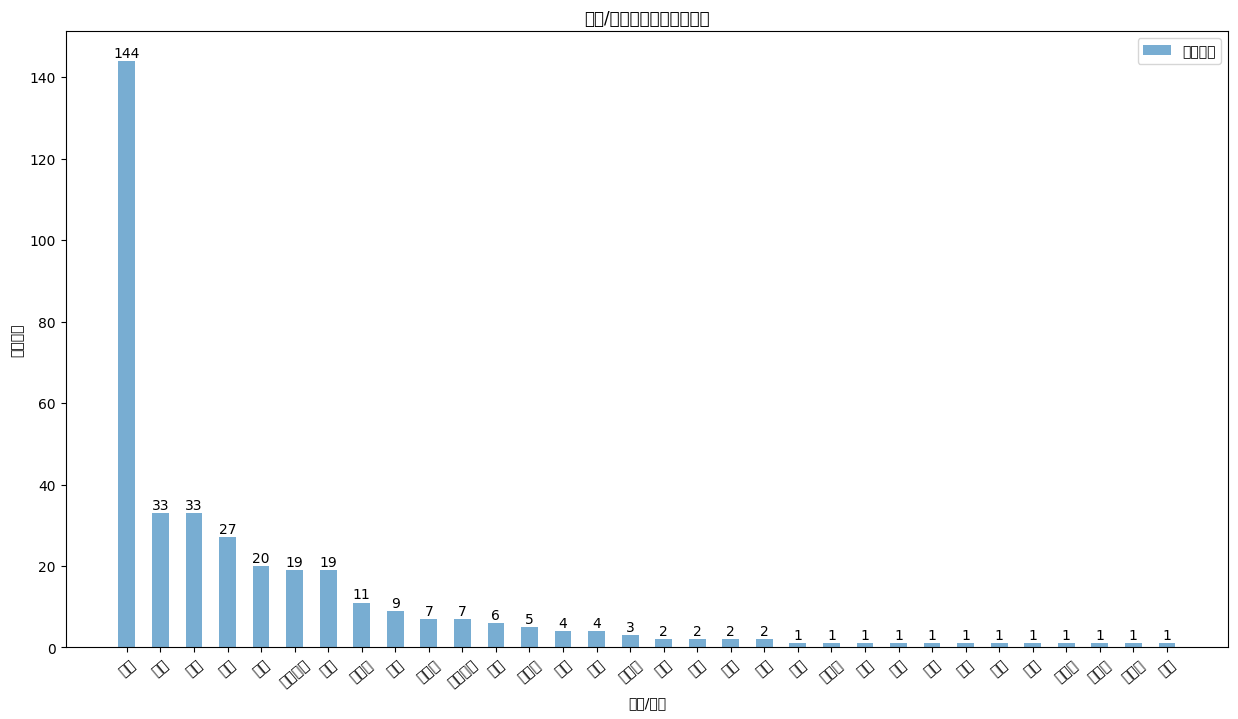

In [39]:


# 创建画布
fig = plt.figure(figsize=(15, 8))

# 添加柱状图数值
# for循环遍历索引和值，zip函数将all_country['all_counts']与其的值配对。
for x, y in zip(range(len(all_country['all_counts'])),all_country['all_counts']):
    # 在每个条形图的上方添加文本，设置水平对齐方式为居中
    plt.text(x, y+1, str(y), ha='center') 


plt.title("国家/地区上榜数的排名情况")
# 绘制条形图
plt.bar(all_country.index, all_country['all_counts'], width=0.5, alpha=0.6, lw=2, label='上榜数量')
plt.xticks( rotation=40)
plt.xlabel("国家/地区")
plt.ylabel("上榜数量")
plt.legend()
plt.show()

# 5、上榜电影类型排名


In [40]:
all_type = df['movie_type'].str.split(' ').apply(pd.Series)
# print(all_type)
# all_type = all_type.apply(pd.value_counts).fillna('0').astype(int)
all_type = all_type.apply(lambda x: x.value_counts()).fillna(0).astype(int)  # 新方法
all_type.columns = ['tpye1','type2','type3','type4','type5']
# all_type['tpye1'] = all_type['tpye1'].astype(int)
# all_type['type2'] = all_type['type2'].astype(int)
# all_type['type3'] = all_type['type3'].astype(int)
# all_type['type4'] = all_type['type4'].astype(int)
# all_type['type5'] = all_type['type5'].astype(int)
all_type.head(10)

all_type['all_counts'] = all_type['tpye1']+all_type['type2']+all_type['type3']+all_type['type4']+all_type['type5']

all_type = all_type.sort_values(['all_counts'],ascending=False)
all_type.head(10)

,tpye1,type2,type3,type4,type5,all_counts
剧情,162,22,5,0,0,189
爱情,3,39,18,0,0,60
喜剧,24,24,0,0,0,48
冒险,6,5,20,12,2,45
犯罪,12,23,7,3,0,45
奇幻,1,15,18,3,0,37
惊悚,0,7,15,11,2,35
动画,14,12,7,2,0,35
动作,17,12,3,0,0,32
悬疑,2,15,13,1,0,31


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

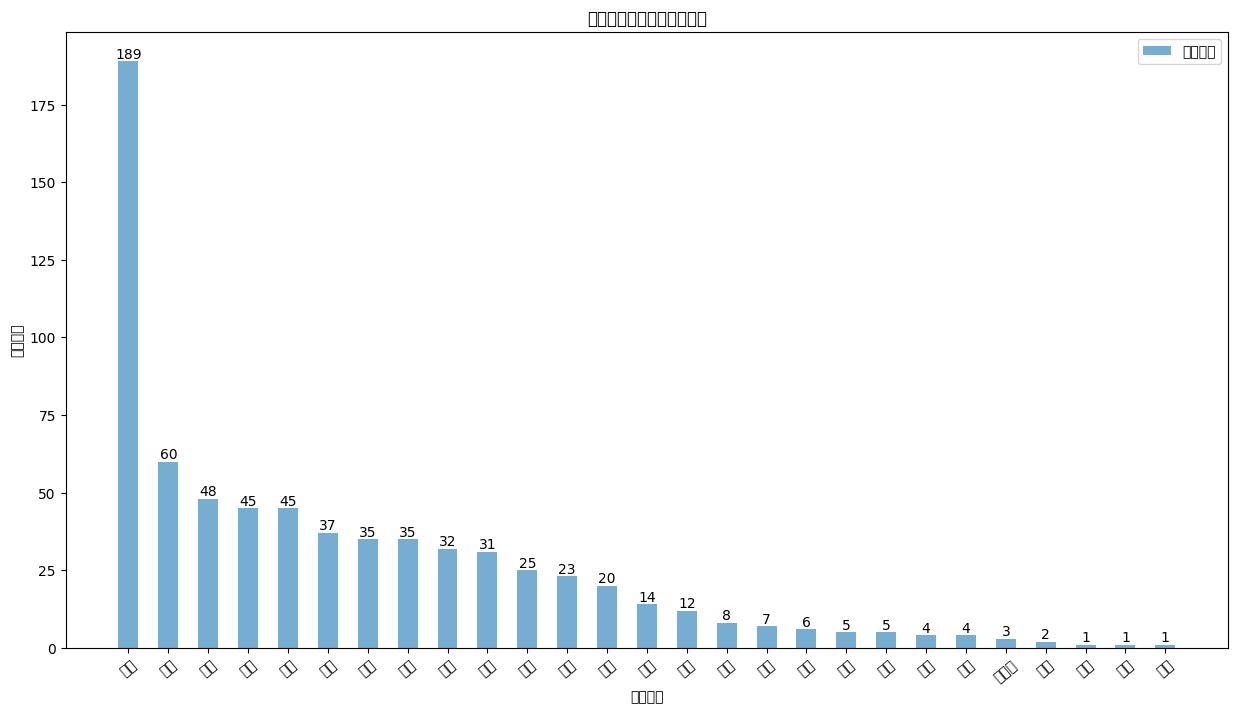

In [41]:
# 创建画布
fig = plt.figure(figsize=(15, 8))

# 添加柱状图数值
for x, y in zip(range(len(all_type['all_counts'])),all_type['all_counts']):
    plt.text(x, y+1, str(y), ha='center') 


plt.title("电影类型上榜数的排名情况")
plt.bar(all_type.index, all_type['all_counts'], width=0.5, alpha=0.6, lw=2, label='上榜数量')
plt.xticks( rotation=40)
plt.xlabel("电影类型")
plt.ylabel("上榜数量")
plt.legend()
plt.show()

In [42]:
"""
词云图制作：
歌词下载：https://lyrics.net.cn/lyrics/71530
在线制作：https://design.weiciyun.com/
"""
# import pandas as pd
# from wordcloud import WordCloud
# import matplotlib.pyplot as plt

# plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
# plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
# print(df['movie_type'])

# # 1. 合并所有电影类型为一个长字符串（以逗号分隔）
# all_types = ' '.join(df['movie_type'].dropna().astype(str))
# print(all_types)

# # 2. 生成词云（中文需指定中文字体，否则显示方框）
# # 如果是中文类型（如“剧情”、“喜剧”），请指定中文字体路径，例如：
# font_path = 'C:/Windows/Fonts/simhei.ttf'  # Windows

# wordcloud = WordCloud(
#     width=800,
#     height=400,
#     background_color='white',
#     font_path=font_path,  # 设置正确路径以支持中文
#     colormap='viridis',
#     collocations=False  # 避免重复词组合
# ).generate(all_types)

# # 3. 显示词云图
# plt.figure(figsize=(12, 6))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')  # 不显示坐标轴
# plt.title("电影类型词云图", fontsize=16)
# plt.show()

'\n词云图制作：\n歌词下载：https://lyrics.net.cn/lyrics/71530\n在线制作：https://design.weiciyun.com/\n'

# 6、上榜次数最多的导演


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23467 (\N{CJK UNIFIED IDEOGRAPH-5BAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23822 (\N{CJK UNIFIED IDEOGRAPH-5D0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39567 (\N{CJK UNIFIED IDEOGRAPH-9A8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Generic family 'sans-serif' not found because none of the following families we

movie_director
宫崎骏 Hayao Miyazaki                  7
克里斯托弗·诺兰 Christopher Nolan          7
史蒂文·斯皮尔伯格 Steven Spielberg          5
王家卫 Kar Wai Wong                    5
李安 Ang Lee                          4
大卫·芬奇 David Fincher                 4
詹姆斯·卡梅隆 James Cameron               3
朱塞佩·托纳多雷 Giuseppe Tornatore         3
刘镇伟 Jeffrey Lau                     3
弗朗西斯·福特·科波拉 Francis Ford Coppola    3
Name: count, dtype: int64


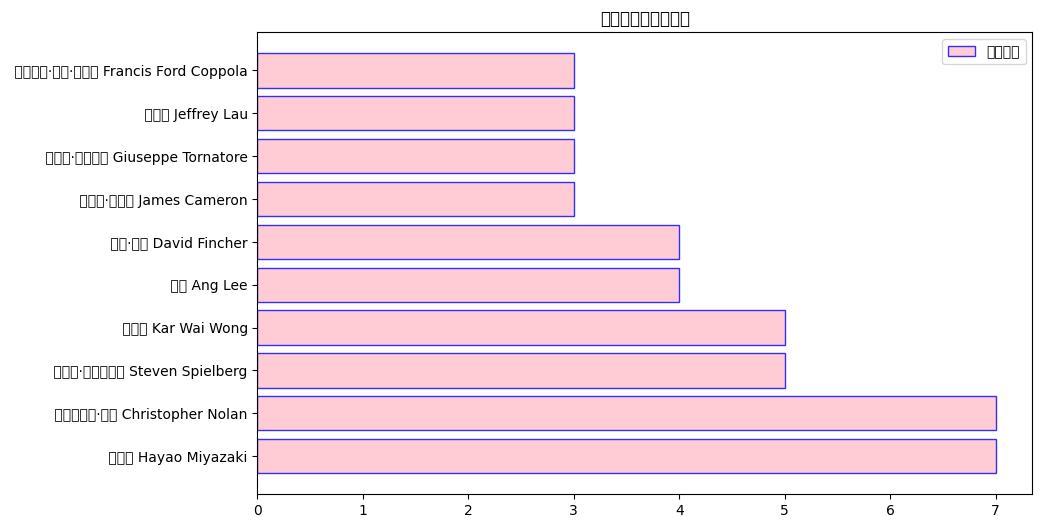

In [43]:
# value_counts()返回一个Series 序列
# 每个导演名称出现的次数，并返回一个Series对象，其中索引是唯一的导演名称，值是对应的计数。
# 并获取前5名导演
director = df['movie_director'].value_counts()[0:10]
print(director)

# 创建画布
fig = plt.figure(figsize=(10, 6))

# 绘制图形
plt.title('导演上榜次数统计图')

# 绘制水平条形图
plt.barh(director.index, director.values, alpha=0.8, facecolor = 'pink', edgecolor = 'blue', label='上榜次数')
plt.legend()
plt.show()

# 7、评分和排名的关系


np.float64(-0.7171361414557141)

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

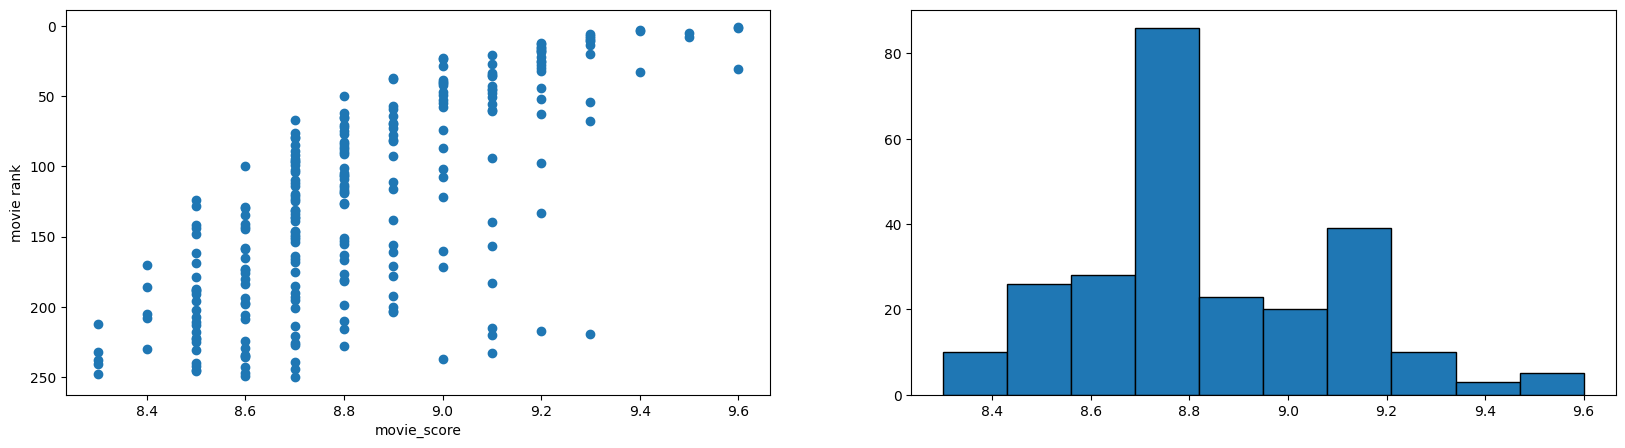

In [44]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.scatter(df['movie_score'],df['movie_num'])
plt.xlabel('movie_score')
plt.ylabel('movie rank')

#修改y轴为倒序
plt.gca().invert_yaxis()

#集中趋势的直方图
plt.subplot(1,2,2)
plt.hist(df['movie_score'],edgecolor='k')

#电影排名和评分的相关性检测，计算皮尔逊相关系数。
df['movie_score'].corr(df['movie_num'])

#out[35]:-0.7171361414557139
# 评分大多是集中在 8.3 - 9.2 之间，随评分的升高，豆瓣Top250排名名次也提前,Pearson相关系数为-0.6923，为强相关性